In [1]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['Malgun Gothic']


In [2]:
# [시계열 기초 3대 가공기법 — 인덱싱, 요약, 상관 분석]
# 1. pd.to_datetime()과 set_index(): 1번 엔진의 매시간 수집된 날짜 데이터를 인덱스로 격상해 시계열을 수립합니다.
# 2. resample('D').mean(): 날씨/설비 가동 데이터의 1시간 해상도를 일단위('D') 평균으로 다운샘플링합니다.
# 3. Series.corr(): 엔진 가동 전 주기 동안 sensor_2(온도 등)와 sensor_7(압력 등) 간의 반비례 음의 상관(-0.94) 관계를 도출합니다.
# * 기계가 닳아 가면서 온도는 상승하고 내부 압력은 떨어지는 등 물리학적 연동 경향이 상관계수로 입증됩니다.
# * `copy()` 옵션 없이 데이터프레임의 특정 서브셋을 떼어내 수정한 뒤 원본에 재할당하려 하면
#   SettingWithCopyWarning 경고가 발생할 수 있으므로, 명시적으로 복사본을 만들어 조작합니다.

ts0 = pd.read_csv('23_cmapss_unit1_timestamp.csv')

ts0['timestamp'] = pd.to_datetime(ts0['timestamp'])
ts0 = ts0.set_index('timestamp')
print('개념 일별 개수:', len(ts0['sensor_2'].resample('D').mean()))   # 8

df = pd.read_csv('23_cmapss_fd001_sample.csv')
u1 = df[df['unit_number'] == 1].copy().reset_index(drop=True)
print('개념 s2-s7 상관:', round(u1['sensor_2'].corr(u1['sensor_7']), 2))   # -0.94

개념 일별 개수: 8
개념 s2-s7 상관: -0.94


## 실습 1. 시간 인덱싱과 슬라이싱
글자 날짜를 시간 형식으로 바꿔 인덱스로 올리고 자르기

목표
- 글자 날짜를 시간 형식으로 바꿔 인덱스로 올리고 날짜로 구간 자르기

단계
- 시각 열의 자료형을 확인하고 시간 형식으로 변환
- 시간 열을 인덱스로 올리기
- 하루·기간을 날짜로 잘라 행 수 확인

예상 결과
- 자료형이 시간으로 바뀌고, 하루 24행·사흘 72행

In [3]:
# [DatetimeIndex를 이용한 특정 일자 및 기간 슬라이싱 실습]
# 1. pd.to_datetime(ts['timestamp']): 날짜 컬럼을 판다스 시간 자료형으로 안전하게 변환합니다.
# 2. ts.loc['2024-01-02']: 하루치를 타겟팅해 해당 날짜의 시간대별 24개 행 데이터를 슬라이싱합니다.
# 3. ts.loc['시작일':'종료일']: 1월 3일부터 5일까지 사흘치 데이터를 범위 기반으로 일괄 여과합니다.
# * 정비 이력서상 특정 설비의 가동 불량이 보고된 날짜 범위의 센서 데이터만 즉시 필터링하여
#   이상이 일어난 세부 시간대를 분석할 때 필수 활용하는 인덱싱 기법입니다.
# * 판다스는 시간 슬라이싱 시 범위의 우측 경계일(종료일)인 1월 5일의 23:59:59 데이터까지 모두 결과에 포함시킵니다.

ts = pd.read_csv('23_cmapss_unit1_timestamp.csv')
ts['timestamp'] = pd.to_datetime(ts['timestamp'])
ts = ts.set_index('timestamp')

print(len(ts.loc['2024-01-02']))                # 24
print(len(ts.loc['2024-01-03':'2024-01-05']))   # 72

24
72


## 실습 2. 리샘플링 집계와 시간 이동통계
시간 단위로 대표값을 구하고 일별 이동평균으로 추세 보기

목표
- 시간 단위로 리샘플링해 대표값을 구하고 일별 이동평균으로 추세를 보기

단계
- 하루 단위 평균과 6시간 단위 평균을 각각 구하기
- 각 결과의 개수로 단위 차이를 확인
- 일별 평균에 이동평균을 걸어 추세를 매끄럽게

예상 결과
- 하루 평균 8개·6시간 평균 32개, 일별 값이 상승 추세

In [4]:
# [일단위 다운샘플링과 롤링 이동평균의 조합 연산]
# 1. ts['sensor_3'].resample('D').mean(): 매 시간 측정치를 매일 단위(Daily)로 뭉뚱그려 날짜별 평균 8개 요약을 얻습니다.
# 2. daily.rolling(3).mean(): 1일 평균으로 축약된 시리즈 위에 다시 3일 크기 이동평균을 체이닝하여 2차 노이즈 제거를 실시합니다.
# * 일주일 동안 매일의 가동 부하가 톱니바퀴처럼 튀더라도, 일별 평균(daily)을 구하고 이에 대한
#   이동평균(daily_ma)까지 입히면 요동이 깔끔히 필터링된 기계 열화의 기저 트렌드를 잡을 수 있습니다.
# * `rolling(3)`을 체이닝하면 daily 데이터의 앞부분 2개 날짜는 계산 불가로 NaN이 주입되므로
#   이후 데이터 연산이나 결측 제거 시 이를 염두에 두어야 합니다.

daily = ts['sensor_3'].resample('D').mean()
print(len(daily), daily.round(1).tolist())
# 8  [1592.1, 1590.9, 1593.3, 1597.8, 1603.7, 1610.6, 1614.1, 1628.5]

print('6시간 개수:', len(ts['sensor_3'].resample('6h').mean()))   # 32
daily_ma = daily.rolling(3).mean()

8 [1592.1, 1590.9, 1593.3, 1597.8, 1603.7, 1610.6, 1614.1, 1628.5]
6시간 개수: 32


## 실습 3. 다중센서 정규화와 겹쳐 비교
여러 센서를 0~1로 맞춰 같은 눈금에서 함께 비교

목표
- 여러 센서를 0~1로 정규화해 같은 눈금에서 함께 비교

단계
- 세 센서를 최소·최대 기준으로 0~1로 정규화
- 정규화 후 최솟값·최댓값이 0과 1인지 확인
- 이동평균을 걸어 겹쳐 그릴 준비

예상 결과
- 각 센서의 최솟값 0·최댓값 1로 눈금이 맞춰짐

In [5]:
# [Min-Max 정규화(Normalization)를 통한 상이한 센서 스케일 통일]
# 1. Min-Max 수식: $(x - min) / (max - min)$을 적용해 최솟값은 0, 최댓값은 1이 되도록 모든 데이터를 스케일링합니다.
# 2. norm.rolling(window=10).mean(): 정규화가 완료되어 [0, 1] 범위로 조율된 센서들에 각각 10-시퀀스 이동평균을 입힙니다.
# * 온도 센서(수백 단위), 전압(수만 단위) 등 물리 스케일이 극도로 대조되는 변수들을 한 공간에서 비교하거나
#   머신러닝 입력 값으로 피드하여 한 변수가 다른 변수를 압도(왜곡)하지 않게 조율하는 머신러닝의 표준적인 변수 정제 방법입니다.
# * 데이터프레임에 바로 최솟값 차감과 격차 나눗셈 연산을 수행하면 판다스가 모든 열(Column)에 대해
#   자동으로 브로드캐스팅(Broadcasting)을 실행해 일괄 연산해 줍니다.

u2 = df[df['unit_number'] == 2].copy().reset_index(drop=True)
cols = ['sensor_2', 'sensor_7', 'sensor_11']

norm = (u2[cols] - u2[cols].min()) / (u2[cols].max() - u2[cols].min())
print(norm.min().tolist(), norm.max().tolist())   # [0,0,0] [1,1,1]

norm_ma = norm.rolling(window=10).mean()

[0.0, 0.0, 0.0] [1.0, 1.0, 1.0]


## 실습 4. 다중센서 변화 폭 비교
센서별 초반·후반을 비교해 변화 폭 큰 감시센서 찾기

목표
- 정규화한 여러 센서의 초반·후반 값을 비교해 변화 폭이 큰 센서를 찾기

단계
- 여섯 센서를 정규화하고 이동평균을 걸기
- 각 센서의 초반과 후반 평균을 구하기
- 초반·후반 차이로 변화 폭이 큰 감시 센서 선별

예상 결과
- sensor_2는 크게 상승, sensor_7은 하락 — 변화 폭 큰 센서 부각

In [6]:
# [정규화 스케일 기반의 다중 센서 전/후기 값 변화량 정량 대조]
# 1. 6개 센서를 선별하여 Min-Max 스케일러로 변환하고 10-윈도우 이동평균을 입혀 부드럽게 가공합니다.
# 2. `iloc[10:40].mean()`: 초기 안정을 찾은 초기 가동 단계의 평균값(e)을 구합니다.
# 3. `iloc[150:].mean()`: 엔진 가동 후기 노후 시점의 평균값(l)을 산출하여 격차(l - e)를 비교합니다.
# * 정규화된 척도 위에서 비교 시, sensor_2는 초기 대비 후기에 +0.46만큼 상승했고, sensor_7은 -0.41만큼 하강했습니다.
#   각 물리 센서가 장비 노화 진행에 따라 얼만큼 정량적으로 변화했는지 동일 척도 위에서 직접 서열을 매깁니다.
# * `iloc[10:40]` 등 행을 인덱싱하여 통계치를 낼 때, 데이터 길이가 40보다 적다면 에러가 날 수 있으므로
#   데이터 총량(`len`)을 먼저 체크하는 방어적 확인이 유익합니다.

sensors = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_15']

n6 = (u2[sensors] - u2[sensors].min()) / (u2[sensors].max() - u2[sensors].min())
n6ma = n6.rolling(window=10).mean()

for c in ['sensor_2', 'sensor_7', 'sensor_11']:
    e = n6ma[c].iloc[10:40].mean(); l = n6ma[c].iloc[150:].mean()
    print(c, round(e, 2), round(l, 2), round(l - e, 2))

# sensor_2 0.07 0.53 +0.46,  sensor_7 0.9 0.49 -0.41,  sensor_11 0.13 0.39 +0.26

sensor_2 0.07 0.53 0.46
sensor_7 0.9 0.49 -0.41
sensor_11 0.13 0.39 0.26


## 실습 5. 다중센서 상관 heatmap
여러 센서의 상관행렬을 색으로 그려 관계 파악

목표
- 여러 센서의 상관행렬을 구해 heatmap으로 함께 움직이는 센서를 파악

단계
- 여섯 센서의 상관행렬을 계산
- 히트맵으로 색과 숫자를 함께 표시
- 진한 칸으로 강한 양·음 관계를 읽기

예상 결과
- sensor_2와 sensor_7이 강한 음(-0.96), sensor_2와 sensor_11이 양(0.84)

s2-s7: -0.96 s2-s11: 0.84


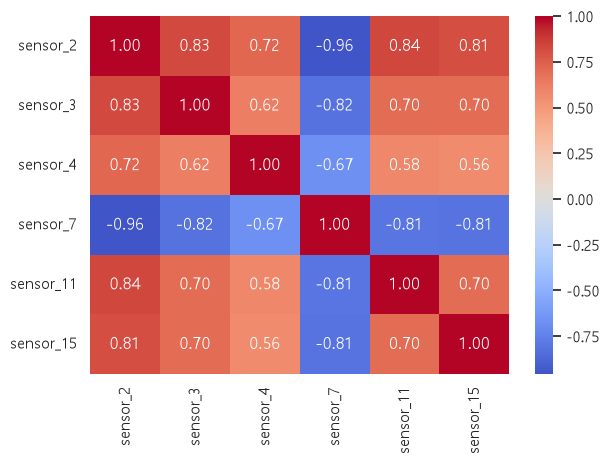

In [7]:
# [2번 엔진의 주요 6개 다변량 센서 간 피어슨 상관행렬 시각화]
# 1. corr(): 모든 센서 열 조합 간의 피어슨 선형 상관계수 행렬을 계산합니다.
# 2. sns.heatmap(..., center=0): 상관 수치 0(상관 없음)을 회색 톤의 기준으로 설정하여 양과 음의 컬러맵 대조를 강조합니다.
# * sensor_2와 sensor_7 간의 상관계수가 -0.96으로 매우 강한 반비례 상관임이 히트맵을 통해 포착됩니다.
#   이는 한 인자가 올라갈 때 다른 인자가 완벽히 하락함을 의미하여, 기계적 열화 인자의 쌍동이 행동을 증명합니다.
# * `fmt='.2f'` 파라미터를 넘겨주어 소수점 둘째 자리까지 숫자 라벨이 뭉개지지 않고 히트맵 내에
#   깨끗하게 마크되도록 조절합니다.

corr = u2[sensors].corr()
print('s2-s7:', round(corr.loc['sensor_2', 'sensor_7'], 2),
      's2-s11:', round(corr.loc['sensor_2', 'sensor_11'], 2))   # -0.96 / 0.84

sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.tight_layout()
plt.show()

## 실습 6. 상관 높은 센서쌍 추출
대각선을 빼고 가장 강한 음·양의 센서쌍 추출

목표
- 상관행렬에서 대각선을 빼고 가장 강한 음·양의 센서쌍을 추출

단계
- 상관행렬에서 자기 자신 대각선을 제외
- 센서쌍을 상관값 순으로 정렬
- 가장 강한 음의 쌍과 양의 쌍을 확인

예상 결과
- 음의 최강쌍 sensor_2·sensor_7(-0.955), 양의 최강쌍 sensor_2·sensor_11(0.839)

In [11]:
# [마스킹 기법과 언스택(unstack)을 이용한 고상관 센서쌍 자동 추출 알고리즘]
# 1. np.eye(len(corr)): 대각 성분(자기 자신과의 상관 1.0 격자)을 표시하는 단위 행렬 불리언 마스크를 만듭니다.
# 2. corr.where(~np.eye...): 자기 자신과의 상관(1.0) 관계 격자들을 전부 NaN으로 지워 버립니다.
# 3. unstack().dropna(): 2차원 행렬 구조를 1차원 인덱스 쌍 시리즈로 풀쳐놓은 후 NaN을 제거합니다.
# 4. map(lambda x: x[0] < x[1]): 중복쌍(A-B와 B-A) 중 알파벳 순 정렬 조건만 필터링하여 유니크한 쌍만 남깁니다.
# * 수십 개의 설비 변수 중에서 가장 관계가 끈끈한 양/음의 관계쌍(최대 음: s2-s7, 최대 양: s11-s2)을
#   컴퓨터가 알아서 발굴하여 분석 리포트의 피처 결합 근거 자료로 제시합니다.
# * lambda 매핑 조건에서 인덱스 튜플 `x`의 두 문자열 크기 대소를 판별함으로써 대칭 관계를 한 개만 추리게 됩니다.

pairs = corr.where(~np.eye(len(corr), dtype=bool)).unstack().dropna()
pairs = pairs[pairs.index.map(lambda x: x[0] < x[1])].sort_values()

print('음:', pairs.index[0], round(pairs.iloc[0], 3))    # ('sensor_2','sensor_7') -0.955
print('양:', pairs.index[-1], round(pairs.iloc[-1], 3))   # ('sensor_11','sensor_2') 0.839

음: ('sensor_2', 'sensor_7') -0.955
양: ('sensor_11', 'sensor_2') 0.839


## 실습 7. 종합 통합 분석
이동통계·변화점을 구하고 구간별 이상 의심 구간 도출

목표
- 이동통계·변화점을 계산하고 구간별로 나눠 이상 의심 구간을 도출

단계
- 이동평균·이동표준편차·변화점을 한 번에 계산
- 초반·후반 변동성과 변화점 개수를 요약
- 회차 구간별 변동성·변화점으로 이상 의심 구간 찾기

예상 결과
- 후반 변동성이 커지고 변화점 19개, 216~288 구간에 집중

In [9]:
# [수명 주기 구간 분할을 통한 이동 변동성 및 이상 변화점 추이 정량 검토]
# 1. sensor_2를 대상으로 10-시퀀스 이동평균(ma)과 이동표준편차(std)를 계산하고, 잔차의 2 표준편차 초과점(is_change)을 `chg`에 담습니다.
# 2. 엔진의 전체 수명 사이클(0~288)을 4개 동등 구간(lo ~ hi)으로 슬라이싱합니다.
# 3. 루프 내에서 각 수명 구간(72 사이클 단위)별 평균 진폭(변동성)과 급변 변화점 발생 누적 개수를 산출해 인쇄합니다.
# * 초기(0~72) 대비 말기(216~288)로 갈수록 변동성(std)이 2.5배 팽창하고 변화점(chg) 발생 횟수가 18개로
#   후반부에 급격히 밀집되는 현상을 수명 분할 데이터로 실증하여, 조만간 설비 고장이 임박했음을 현장에 경고합니다.
# * 구간 필터링 조건 `(u2.time_cycles > lo) & (u2.time_cycles <= hi)` 기입 시, 각 조건에 괄호를
#   치고 비트 AND(&) 기호로 병합해야 파이썬 우선순위 연산 에러를 막을 수 있습니다.

s = u2['sensor_2']

u2['ma'] = s.rolling(10).mean()
u2['std'] = s.rolling(10).std()

resid = s - u2['ma']
u2['chg'] = resid.abs() > 2 * resid.std()

print('변동성 초반/후반:', round(u2['std'].iloc[10:50].mean(), 3), round(u2['std'].iloc[150:].mean(), 3))  # 0.319 / 0.516
print('변화점:', int(u2['chg'].sum()))            # 19

for lo, hi in ((0, 72), (72, 144), (144, 216), (216, 288)):
    seg = u2[(u2.time_cycles > lo) & (u2.time_cycles <= hi)]
    print(f'  {lo}~{hi}: 변동성 {seg["std"].mean():.3f}, 변화점 {int(seg["chg"].sum())}개')

# 216~288 변동성 0.723, 변화점 18개 (후반 집중)

변동성 초반/후반: 0.319 0.516
변화점: 19
  0~72: 변동성 0.304, 변화점 0개
  72~144: 변동성 0.311, 변화점 1개
  144~216: 변동성 0.295, 변화점 0개
  216~288: 변동성 0.723, 변화점 18개
